# **Bayesian Optimization - Maximizing the rate of Formic Acid Decomposition using a defined Design Space**



#Installation
First, we need to install the necessary libraries.

Restart the runtime after installation.

In [70]:
!pip install -q uv
!uv venv --python=3.10
!uv pip install scikit-learn-extra pytorch_lightning transformers botorch gpytorch rdkit numpy==1.26.4
!uv pip install tabicl

Using CPython 3.10.12 interpreter at: /usr/bin/python3.10
Creating virtual environment at: .venv
? A virtual environment already exists at `.venv`. Do you want to replace it? [y/n] › yes

hint: Use the `--clear` flag or set `UV_VENV_CLEAR=1` to skip this prompt^C
Using Python 3.12.13 environment at: /usr
Checked 7 packages in 106ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 105ms


***Note: remember to restart the runtime after the installation.***

# Necessary Imports for the Notebook

Now that the libraries are installed, let's import all the necessary datasets and modules for this notebook.

In [71]:
!wget https://raw.githubusercontent.com/guillaumebedouelle-cloud/AIforchem/main/formic_acid_decomposition_CatTestHub.csv -O formic_acid_decomposition_CatTestHub.csv

--2026-05-24 09:21:21--  https://raw.githubusercontent.com/guillaumebedouelle-cloud/AIforchem/main/formic_acid_decomposition_CatTestHub.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25008 (24K) [text/plain]
Saving to: ‘formic_acid_decomposition_CatTestHub.csv’

formic_acid_decompo 100%[===================>]  24.42K  --.-KB/s    in 0.005s  

2026-05-24 09:21:22 (5.01 MB/s) - ‘formic_acid_decomposition_CatTestHub.csv’ saved [25008/25008]



In [72]:
!wget https://raw.githubusercontent.com/schwallergroup/ai4chem_course/main/notebooks/10%20-%20Bayesian%20optimization/base_fingerprint_kernel.py -O base_fingerprint_kernel.py
!wget https://raw.githubusercontent.com/schwallergroup/ai4chem_course/main/notebooks/10%20-%20Bayesian%20optimization/tanimoto_kernel.py -O tanimoto_kernel.py
!wget https://raw.githubusercontent.com/schwallergroup/ai4chem_course/main/notebooks/10%20-%20Bayesian%20optimization/utils.py -O utils.py

--2026-05-24 09:21:22--  https://raw.githubusercontent.com/schwallergroup/ai4chem_course/main/notebooks/10%20-%20Bayesian%20optimization/base_fingerprint_kernel.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5126 (5.0K) [text/plain]
Saving to: ‘base_fingerprint_kernel.py’

base_fingerprint_ke 100%[===================>]   5.01K  --.-KB/s    in 0s      

2026-05-24 09:21:22 (51.1 MB/s) - ‘base_fingerprint_kernel.py’ saved [5126/5126]

--2026-05-24 09:21:22--  https://raw.githubusercontent.com/schwallergroup/ai4chem_course/main/notebooks/10%20-%20Bayesian%20optimization/tanimoto_kernel.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.gith

In [73]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import gpytorch
from gpytorch.kernels import ScaleKernel, Kernel
from gpytorch.mlls import ExactMarginalLogLikelihood

from botorch.models.gp_regression import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.models.transforms.input import Normalize
from botorch.acquisition import UpperConfidenceBound
from botorch import fit_gpytorch_mll
from tanimoto_kernel import TanimotoKernel


from sklearn_extra.cluster import KMedoids
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

from tabicl import TabICLRegressor
from pytorch_lightning import seed_everything

# Loading formic acid decomposition datasets from CPEC Chemical Catalysis Database and selecting BO features and target


We will focus on the Formic Acid Decomposition dataset for this notebook.
First, load the

In [74]:
# Load Formic Acid Decomposition dataset
formic_df = pd.read_csv(
    "formic_acid_decomposition_CatTestHub.csv",
    sep=";",
    encoding="utf-8-sig"
)

# Universal renaming dictionary for both datasets (see Notebook with both datasets, merged dataset and models comparison)
rename_universal = {
    'Active Site Density [µmol gcat-1]': 'Active Site Density [umol gcat-1]',
    'Active Site Density [μmol gcat-1]': 'Active Site Density [umol gcat-1]',
    'Selectivity CO₂ [%]': 'Selectivity CO2 [%]',
    'Selectivity CO2 [%]': 'Selectivity CO2 [%]',
    'Selectivity CH4 [%]': 'Selectivity CH4 [%]',
    'Selectivity H₂ [%]': 'Selectivity H2 [%]',
    'CO, Inlet Mol fraction [%]': 'CO, Inlet Mole fraction [%]',
    'CO₂, Inlet Mol fraction [%]': 'CO2, Inlet Mole fraction [%]',
    'H₂, Inlet Mol fraction [%]': 'H2, Inlet Mole fraction [%]',
    'H₂O, Inlet Mol fraction [%]': 'H2O, Inlet Mole fraction [%]',
    'Formic Acid, Inlet Mol fraction [%]': 'Formic Acid, Inlet Mole fraction [%]',
    'Inert, Inlet Mol fraction [%]': 'Inert, Inlet Mole fraction [%]',
    'Inert, Inlet mole fraction [%] ': 'Inert, Inlet Mole fraction [%]',
    'Molecular Weight of Active component [g mol⁻¹]': 'Molecular Weight of Active component [g mol-1]',
    'Molecular Weight of Active component [g mol]': 'Molecular Weight of Active component [g mol-1]',
    'Rate [μmol gcat⁻¹ min⁻¹]': 'Rate [umol gcat-1 min-1]',
    'Rate [μmol product gcat-1min-1]': 'Rate [umol gcat-1 min-1]',
    'STY [mol product mol active site⁻¹ hr⁻¹ ]': 'STY [mol product mol active site-1 hr-1]',
    'Weight Hourly Space Velocity [gHCOOH gcat⁻¹ hr⁻¹]': 'WHSV [g reactant gcat-1 hr-1]',
    'Inert Used': 'Inlet Inert Used',
}
formic_df = formic_df.rename(columns=rename_universal)

# Select target and features
target = 'Rate [umol gcat-1 min-1]'
bo_features = [
    'Metal', 'Support', 'Temperature [K]', 'Total Pressure [kPa]',
    'WHSV [g reactant gcat-1 hr-1]', 'Inlet Inert Used',
    'Formic Acid, Inlet Mole fraction [%]', 'CO2, Inlet Mole fraction [%]',
    'H2, Inlet Mole fraction [%]'
]

# Categorical columns
cat_cols = ['Metal', 'Support', 'Inlet Inert Used']

# Numerical columns
num_cols = [c for c in bo_features if c not in cat_cols]

# Prepare to train the TabICL on our dataset
formic_df = formic_df.dropna(subset=bo_features + [target])

X_formic = formic_df[bo_features]
y_formic = formic_df[target]

X_formic_encoded = pd.get_dummies(X_formic, columns=cat_cols, dtype=float)

In [75]:
X_formic_encoded.head()

,Temperature [K],Total Pressure [kPa],WHSV [g reactant gcat-1 hr-1],"Formic Acid, Inlet Mole fraction [%]","CO2, Inlet Mole fraction [%]","H2, Inlet Mole fraction [%]",Metal_Gold,Metal_Palladium,Metal_Platinum,Support_Alumina,Support_Carbon,Support_Silica,Support_Silicon Carbide,Inlet Inert Used_Helium,Inlet Inert Used_Nitrogen
0,358,101.33,7.7,2.61,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,363,101.33,7.7,2.61,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,368,101.33,7.7,2.61,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,373,101.33,7.7,2.61,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,378,101.33,7.7,2.61,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


# Train TabICL Regressor on our dataset

The goal is to simulate experiments that we cannot realistically run for the scope of this project for a Bayesian Optimisation with many iterations.

In [76]:
tabicl = TabICLRegressor(random_state=42)
tabicl.fit(X_formic_encoded, y_formic)

TabICLRegressor()

# Generate a design space
A design space matrix is constructed from our data to look for the optimal experiments to maximize the rate of reaction. The 10 experiments with the highest reaction rate are used to build the design space.

In [77]:
best_experiments=formic_df.sort_values('Rate [umol gcat-1 min-1]',ascending=False)
best_experiments=best_experiments.iloc[:10]

In [78]:
best_experiments['Rate [umol gcat-1 min-1]']

,Rate [umol gcat-1 min-1]
24,1484.97
23,793.10
28,434.35
26,434.35
25,434.35
37,409.49
30,409.24
29,409.24
27,409.24
36,409.24


In [79]:
# Categorical features - check the unique ones
metals = sorted(best_experiments["Metal"].dropna().unique())
supports = sorted(best_experiments["Support"].dropna().unique())
inert = sorted(best_experiments["Inlet Inert Used"].dropna().unique())

In [80]:
metals, supports, inert # we see those are already defined because only one choice for each

(['Palladium'], ['Carbon'], ['Helium'])

In [81]:
# Numerical features
def delta_value(val_min, val_max):
  return (val_max-val_min)/3 # arbitrary search beyond the already explored space

min_T, max_T = best_experiments["Temperature [K]"].min(), best_experiments["Temperature [K]"].max()

min_P, max_P = best_experiments["Total Pressure [kPa]"].min(), formic_df["Total Pressure [kPa]"].max()

min_WHSV, max_WHSV = best_experiments["WHSV [g reactant gcat-1 hr-1]"].min(), best_experiments["WHSV [g reactant gcat-1 hr-1]"].max()

min_fa, max_fa = best_experiments['Formic Acid, Inlet Mole fraction [%]'].min(), best_experiments['Formic Acid, Inlet Mole fraction [%]'].max()

min_co2, max_co2 = best_experiments['CO2, Inlet Mole fraction [%]'].min(), best_experiments['CO2, Inlet Mole fraction [%]'].max()

T_grid = np.linspace(min_T-delta_value(min_T, max_T), max_T+delta_value(min_T, max_T), 5)
P_grid = np.linspace(min_P-delta_value(min_P, max_P), max_P+delta_value(min_P, max_P), 5)
WHSV_grid = np.linspace(min_WHSV-delta_value(min_WHSV, max_WHSV), max_WHSV+delta_value(min_WHSV, max_WHSV), 5)
fa_grid = np.linspace(min_fa-delta_value(min_fa, max_fa), max_fa+delta_value(min_fa, max_fa), 5)
co2_grid = np.linspace(0, max_co2+delta_value(min_co2, max_co2), 5)
h2_grid = best_experiments['H2, Inlet Mole fraction [%]'].dropna().unique() # it is 0 for each of the top 10 experiments

In [82]:
design_space = []
for m, s, T, P, whsv, i, fa, co2, h2 in itertools.product(metals, supports, T_grid, P_grid, WHSV_grid, inert, fa_grid, co2_grid, h2_grid):
    design_space.append([m, s, T, P, whsv, i, fa, co2, h2])

design_df = pd.DataFrame(design_space, columns=bo_features)

# Final design space
X_design = pd.get_dummies(design_df, columns= cat_cols, dtype=float)


We realize we will now have a shape issue.

In [83]:
X_design.shape, X_formic_encoded.shape

((3125, 9), (84, 15))

Let's add the missing columns and set them to zero.

In [84]:
extra_columns=set(X_formic_encoded.columns) - set(X_design.columns)
for c in extra_columns:
  X_design[c] = 0.0

X_design = X_design[X_formic_encoded.columns] # keep the same column order

Sanity checks.

In [85]:
X_design.shape, X_formic_encoded.shape

((3125, 15), (84, 15))

In [86]:
# Check and visualise
X_design.head()

,Temperature [K],Total Pressure [kPa],WHSV [g reactant gcat-1 hr-1],"Formic Acid, Inlet Mole fraction [%]","CO2, Inlet Mole fraction [%]","H2, Inlet Mole fraction [%]",Metal_Gold,Metal_Palladium,Metal_Platinum,Support_Alumina,Support_Carbon,Support_Silica,Support_Silicon Carbide,Inlet Inert Used_Helium,Inlet Inert Used_Nitrogen
0,366.333333,95.806667,3.966667,0.663333,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,366.333333,95.806667,3.966667,0.663333,3.593333,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,366.333333,95.806667,3.966667,0.663333,7.186667,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,366.333333,95.806667,3.966667,0.663333,10.780000,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,366.333333,95.806667,3.966667,0.663333,14.373333,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


# Initial data selection

The BOInitData from class can be reused to select initial data: https://colab.research.google.com/github/schwallergroup/ai4chem_course/blob/main/notebooks/10%20-%20Bayesian%20optimization/Buchwald-Hartwig-BO.ipynb#scrollTo=QOJzAypcZ6Bw

In [87]:
class BOInitData:
    def __init__(self,
                 n: int = 10,
                 method: str = 'random',
                 metric: str = 'jaccard',
                 cluster_init: str = 'random',
                 seed: int = 42):
        self.n = n
        self.method = method
        self.seed = seed
        self.metric = metric
        self.cluster_init = cluster_init

        self.method_map = {
            'kmedoids': self.kmedoids,
            'kmeans': self.kmeans,
            'max_min_dist': self.max_min_dist,
            'random': self.random,
        }

    def fit(self, x):
        init_method = self.method_map.get(self.method)
        if init_method is None:
            raise ValueError(f"Unrecognized initialization method '{self.method}'")
        return init_method(x)

    def kmedoids(self, x):
        kmedoids = KMedoids(
            n_clusters=self.n,
            init=self.cluster_init,
            random_state=self.seed,
            metric=self.metric,
            max_iter=5000,
        ).fit(x)
        selected = torch.tensor(kmedoids.medoid_indices_.tolist())
        return selected

    def kmeans(self, x):
        scaler = StandardScaler()
        x_init_normalized = scaler.fit_transform(x)
        kmeans = KMeans(
            n_clusters=self.n,
            init=self.cluster_init,
            random_state=self.seed,
            max_iter=5000,
        ).fit(x_init_normalized)
        centroids = torch.tensor(kmeans.cluster_centers_)
        selected = torch.argmin(torch.norm(torch.from_numpy(x).unsqueeze(1) - centroids, dim=2), dim=0)
        return selected

    def max_min_dist(self, x):
        distances = cdist(x, x, metric=self.metric)
        np.random.seed(self.seed)
        selected = [np.random.randint(0, x.shape[0])]

        for _ in range(self.n - 1):
            dist_to_selected = distances[:, selected]
            min_distances = np.min(dist_to_selected, axis=1)
            next_idx = np.argmax(min_distances)
            selected.append(next_idx)
        return torch.tensor(selected, dtype=torch.long)

    def random(self, x):
        selected = torch.randperm(len(x))[: self.n]
        return selected

In [88]:
def make_initial_data(X_design, tabicl, n_init=10, method='max_min_dist', seed=0):
    init_selector = BOInitData(n=n_init, method=method, metric='euclidean', seed=seed)
    init_idx = init_selector.fit(X_design.values)

    X0 = torch.tensor(X_design.values[init_idx], dtype=torch.float64)
    X0_df = pd.DataFrame(X_design.values[init_idx], columns=X_design.columns)
    y0_pred = tabicl.predict(X0_df)
    y0 = torch.tensor(y0_pred, dtype=torch.float64).reshape(-1, 1)
    return X0, y0

# Surrogate Model

We build a Gaussian Process surrogate model with Botorch library, the code is copied from the course exercise: https://colab.research.google.com/github/schwallergroup/ai4chem_course/blob/main/notebooks/10%20-%20Bayesian%20optimization/Buchwald-Hartwig-BO.ipynb#scrollTo=rcUMHxFXZ6Bz

In [89]:
class GP(SingleTaskGP):
    def __init__(
        self,
        train_x: torch.Tensor,
        train_y: torch.Tensor,
        kernel: Kernel = None,
        standardize: bool = True,
        normalize: bool = False,
    ):
        super().__init__(
            train_x,
            train_y,
            covar_module=ScaleKernel(base_kernel=kernel),
            outcome_transform=Standardize(train_y.shape[-1]) if standardize else None,
            input_transform=Normalize(train_x.shape[-1]) if normalize else None,
        )

        self.kernel = kernel
        self.standardize = standardize
        self.normalize = normalize

    def reinit(self, train_x, train_y):
        return GP(
            train_x,
            train_y,
            self.kernel,
            self.standardize,
            self.normalize,
        )


# Bayesian Optimization Loop

A best candidate is identified for every run and the value associated to this set of datapoint is predicted using TabICL. The code is adaptated from the class exercise.

In [90]:
def run_bo_simulated(X_design, tabicl, n_init=10, num_iterations=30, seed=0):
    train_x, train_y = make_initial_data(X_design, tabicl, n_init=n_init, method='max_min_dist', seed=seed)

    # Available points
    heldout_x = torch.tensor(X_design.values, dtype=torch.float64)

    # Initialize GP
    gp = GP(train_x, train_y, kernel=TanimotoKernel())
    gp.double()
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)

    # Get best value
    best_value = train_y.max().item()
    best_values = [best_value]
    final_best_candidate = None

    for i in range(num_iterations):
        # Find best candidate
        with gpytorch.settings.fast_computations(covar_root_decomposition=False):
            fit_gpytorch_mll(mll, max_retries=50)

        acq_func = UpperConfidenceBound(gp, beta=0.25)
        acq_values = acq_func(heldout_x.unsqueeze(-2))
        best_candidate_idx = acq_values.argmax()
        best_candidate = heldout_x[best_candidate_idx].reshape(1, -1)

        # Convert into DataFrame
        best_candidate_df = pd.DataFrame(best_candidate.cpu().numpy(), columns=X_design.columns)

        # Predict value using TabICL
        pred = tabicl.predict(best_candidate_df)[0]
        value_best_candidate = torch.tensor([[pred]], dtype=torch.float64)

        # Update training sets
        train_x = torch.vstack([train_x, best_candidate])
        train_y = torch.vstack([train_y, value_best_candidate])

        # Remove chosen element from candidates
        heldout_x = torch.cat([heldout_x[:best_candidate_idx], heldout_x[best_candidate_idx +1:]])

        # Reinitialize GP
        gp = gp.reinit(train_x, train_y)
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)

        # Find best value
        new_best_value = max(best_value, value_best_candidate.item())
        if new_best_value > best_value:
          best_value = new_best_value
          final_best_candidate = best_candidate_df
        best_values.append(best_value)

    return np.array(best_values), final_best_candidate

# Random Search Loop

The Bayesian Optimisation Loop will be compared to a Random Search Loop, where candidates are chosen randomly among the available pool. The code is adaptated from the class exercise.

In [91]:
def run_random_search_simulated(X_design, tabicl, n_init=10, num_iterations=30, seed=1):
    train_x, train_y = make_initial_data(X_design, tabicl, n_init=n_init, method='max_min_dist', seed=seed)

    # Available points
    heldout_x = torch.tensor(X_design.values, dtype=torch.float64)

    # Get best value
    best_value = train_y.max().item()
    best_values = [best_value]

    for i in range(num_iterations):
        # Randomly select next candidate
        idx = torch.randint(heldout_x.size(0), (1,)).item()
        candidate = heldout_x[idx].reshape(1, -1)

        # Convert into DataFrame
        candidate_df = pd.DataFrame(candidate.cpu().numpy(), columns=X_design.columns)

        # Predict value using TabICL
        pred = tabicl.predict(candidate_df)[0]
        value_candidate = torch.tensor([[pred]], dtype=torch.float64)

        # Update training sets
        train_x = torch.vstack([train_x, candidate])
        train_y = torch.vstack([train_y, value_candidate])
        heldout_x = torch.cat([heldout_x[:idx], heldout_x[idx+1:]])

        # Find best value
        best_value = max(best_value, value_candidate.item())
        best_values.append(best_value)

    # Get best conditions
    best_idx = train_y.argmax().item()
    best_condition = train_x[best_idx]
    best_condition = X_design.iloc[best_idx]
    return np.array(best_values)

# Run Bayesian Optimization for 100 iterations

In [92]:
seed_everything(42)

iterations = 100
best_values_bo, final_best_candidate = run_bo_simulated(X_design, tabicl, n_init=5, num_iterations=iterations, seed=42)
best_values_random = run_random_search_simulated(X_design, tabicl, n_init=5, num_iterations=iterations, seed=42)

INFO:lightning_fabric.utilities.seed:Seed set to 42


# Plot 'best so far' rate

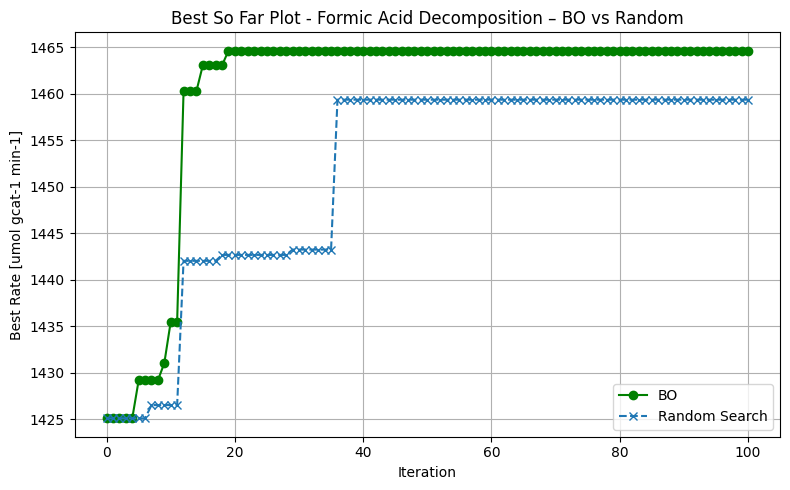

In [93]:
plt.figure(figsize=(8, 5))
plt.plot(best_values_bo, label='BO', marker='o', color = 'green')
plt.plot(best_values_random, label='Random Search', marker='x', linestyle='--')
plt.xlabel("Iteration")
plt.ylabel("Best Rate [umol gcat-1 min-1]")
plt.title("Best So Far Plot - Formic Acid Decomposition – BO vs Random")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

BO is more effective than random search.

One can also notice that the rates are all lower than the best experimental rate (1484.97 umol/gcat/min). However, because the iterations were simulated, it is more meaningful to compare to the highest predicted rate.

Let's compare the true rates with the predicted rates.


In [94]:
# Top 10 rates
idx_best = y_formic.nlargest(10).index
top10_encoded = X_formic_encoded.loc[idx_best]

predicted_best = []

for _, row in top10_encoded.iterrows():
    row_df = row.to_frame().T   # convert to DataFrame
    pred = tabicl.predict(row_df)[0]
    predicted_best.append(pred)

# Comparison table
compared_predictions_experiments = pd.DataFrame({
    'True Rate [umol gcat-1 min-1]': y_formic.nlargest(10).values,
    'Predicted Rate [umol gcat-1 min-1]': predicted_best
})

compared_predictions_experiments

,True Rate [umol gcat-1 min-1],Predicted Rate [umol gcat-1 min-1]
0,1484.97,1457.376953
1,793.10,802.724609
2,434.35,429.762939
3,434.35,440.521027
4,434.35,408.965271
5,409.49,398.400879
6,409.24,411.060760
7,409.24,408.965271
8,409.24,408.965271
9,409.24,398.201904


The rates predicted by the BO after a dozen iterations are therefore higher than the maximum predicted rate using existing experimental points.

BO therefore seems to have identified points of the design space worth exploring to maximize the rate.